In [28]:
import numpy as np
import math 
import random
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
import time
from scipy.linalg import expm
from numpy import linalg as LA

def generate_rotation(axis, angle):

    # Last modified: 13 March 2019

    """
    Generates the rotation matrix about the given axis (unit vector in Cartesian coordinates) by the given angle.
    """

    # Generators of the SO(3) rotations
    Lx = np.matrix([[0, 0, 0], [0, 0, -1], [0, 1, 0]])
    Ly = np.matrix([[0, 0, 1], [0, 0, 0], [-1, 0, 0]])
    Lz = np.matrix([[0, -1, 0], [1, 0, 0], [0, 0, 0]])

    n1 = axis[0]
    n2 = axis[1]
    n3 = axis[2]

    L = n1 * Lx + n2 * Ly + n3 * Lz

    return np.matrix(expm(angle * L))

def generate_rotation_approx(axis, angle):

    # Last modified: 13 March 2019

    """
    Generates the rotation matrix about the given axis (unit vector in Cartesian coordinates) by the given angle.
    """

    # Generators of the SO(3) rotations
    Lx = np.matrix([[0, 0, 0], [0, 0, -1], [0, 1, 0]])
    Ly = np.matrix([[0, 0, 1], [0, 0, 0], [-1, 0, 0]])
    Lz = np.matrix([[0, -1, 0], [1, 0, 0], [0, 0, 0]])

    n1 = axis[0]
    n2 = axis[1]
    n3 = axis[2]

    L = n1 * Lx + n2 * Ly + n3 * Lz
    
    M = np.identity(3) + angle*L #+ 0.5*(angle**2)*L*L 

    return np.matrix(M)

def evolve_vector(init_point, axis, omega, T):

    """
    Performs rotation of a given initial point (init_point, in Cartesian coordinates) by the given axis
    (unit vector in Cartesian coordinates) at a given rotation speed (omega) for a time T (starting at t = 0).
    """

    init_point = np.matrix(init_point).H

    R = generate_rotation(axis, omega * T)
    point_t = R * init_point

    point_t_x = np.array(point_t[0])[0][0]
    point_t_y = np.array(point_t[1])[0][0]
    point_t_z = np.array(point_t[2])[0][0]

    return [point_t_x, point_t_y, point_t_z]

def evolve_vector_approx(init_point, axis, omega, T):

    """
    Performs rotation of a given initial point (init_point, in Cartesian coordinates) by the given axis
    (unit vector in Cartesian coordinates) at a given rotation speed (omega) for a time T (starting at t = 0).
    """

    init_point = np.matrix(init_point).H

    R = generate_rotation_approx(axis, omega * T)
    point_t = R * init_point

    point_t_x = np.array(point_t[0])[0][0]
    point_t_y = np.array(point_t[1])[0][0]
    point_t_z = np.array(point_t[2])[0][0]

    return [point_t_x, point_t_y, point_t_z]

def generate_point(R, theta, phi):

    """
    Generates (in Cartesian coordinates) the point in 3D specified by
    the spherical coordinates R, theta, phi
    Here, phi is the azimuthal angle (positive going counter-clockwise from the positive x-axis), and
    theta is the polar angle (positive going down from the z-axis)
    """

    return [R * np.sin(theta) * np.cos(phi), R * np.sin(theta) * np.sin(phi), R * np.cos(theta)]

def dst(a, b):
    
    return ((a[0]-b[0])**2 + (a[1]-b[1])**2 + (a[2]-b[2])**2)**0.5

def eta(L, h, r, R, eff):
    lam = 810e-9;
    eta_zen = 0.5;
    sigma = 0;

    secZ = 1 / ((h / L) - (L**2 - h**2) / (2 * R * L));

    eta_atm2 = eta_zen**secZ;

    w0 = .8 * r;  # initial waist of optical beam

    theta_d = lam / (np.pi * w0);  # beam divergence angle

    wL = (w0**2 + (theta_d**2 + sigma**2) * (L**2))**0.5;  # beam waist at receiving OGS, a distance L away from transmitter

    eta_sg = 1 - np.exp(-2 * R**2 / wL**2);  # diffraction-lim transmittance

    efficiency = eta_sg * eta_atm2 * eff;
    
    return efficiency



#implementation for 2 ground stations and 1 polar satellite

#constants

c = 2.9978e8
R = 6371e3
h = 500e3
G = 6.67408e-11
M = 5.972e24
om = (G*M/(R+h)**3)**0.5
Om = 2*np.pi/24/3600
pair_rate = 1e7


def bellsshadow(lat,long,eff_gs_sat,T): 
    
    #shadow plot code
    dt = 1/pair_rate
    steps = math.floor(T/dt)
    tarray = np.array([i*dt for i in range(steps)])

    #trajectory

    r_gs = R
    r_sat = R+h
    
    sat = generate_point(r_sat, 90*np.pi/180, 0)
    gs = generate_point(r_gs, lat, long)
    dist = dst(sat,gs)

    #basis and spin data points

    a1b1=np.array([0])
    a2b1=np.array([0])
    a1b2=np.array([0])
    a2b2=np.array([0])
    
    #naming each basis

    a1=1
    a2=2
    b1=3
    b2=4
    up=1
    dn=-1

    #basis

    sz=np.array([[1,0],[0,-1]])
    sx=np.array([[0,1],[1,0]])
    B=(-1/math.sqrt(2))*(sz+sx)
    Bb=(1/math.sqrt(2))*(sz-sx)#B prime

    #eigen values and vectors 

    a1va, A1 = LA.eig(sz)
    idx=np.argsort(a1va)
    a1va=a1va[idx]
    A1=A1[:,idx]
    a2va, A2 = LA.eig(sx)
    idx=np.argsort(a2va)
    a2va=a2va[idx]
    A2=A2[:,idx]
    b1va, B1 = LA.eig(B)
    idx=np.argsort(b1va)
    b1va=b1va[idx]
    B1=B1[:,idx]
    b2va, B2 = LA.eig(Bb)
    idx=np.argsort(b2va)
    b2va=b2va[idx]
    B2=B2[:,idx]

    #naming each eigen vector

    a1p=A1[:,1]
    a1n=A1[:,0]
    a2p=A2[:,1]
    a2n=A2[:,0]
    b1p=B1[:,1]
    b1n=B1[:,0]
    b2p=B2[:,1]
    b2n=B2[:,0]

    #probabilities

    a1b1pp=(np.dot(b1p,a1n))**2 
    a1b1nn=(np.dot(b1n,a1p))**2
    a1b2pp=(np.dot(b2p,a1n))**2
    a1b2nn=(np.dot(b2n,a1p))**2
    a2b1pp=(np.dot(b1p,a2n))**2
    a2b1nn=(np.dot(b1n,a2p))**2
    a2b2pp=(np.dot(b2p,a2n))**2
    a2b2nn=(np.dot(b2n,a2p))**2

   
        
    for t in range(steps):

        abasis=random.choice([a1,a2])#50 chance basis
        aspin=random.choice([up,dn])#50 chance spin

        if random.random()<=eff_gs_sat: #photon makes it to sat -- later add the visibility condition here when dynamics is also included
            bbasis=random.choice([b1,b2]) #50/50 chance
            if bbasis == b1:
                if abasis==1:
                    if aspin==up:
                        if random.random()<=(a1b1pp):
                            bspin=up
                            a1b1=np.append(a1b1,[(aspin*bspin)])
                        else:
                            bspin=dn
                            a1b1=np.append(a1b1,[(aspin*bspin)])
                    if aspin==dn:
                        if random.random()<=(a1b1nn):
                            bspin=dn
                            a1b1=np.append(a1b1,[(aspin*bspin)])
                        else:
                            bspin=up
                            a1b1=np.append(a1b1,[(aspin*bspin)])
                if abasis==2:
                    if aspin==up:
                        if random.random()<=(a2b1pp):
                            bspin=up
                            a2b1=np.append(a2b1,[(aspin*bspin)])
                        else:
                            bspin=dn
                            a2b1=np.append(a2b1,[(aspin*bspin)])
                    if aspin==dn:
                        if random.random()<=(a2b1nn):
                            bspin=dn
                            a2b1=np.append(a2b1,[(aspin*bspin)])
                        else:
                            bspin=up
                            a2b1=np.append(a2b1,[(aspin*bspin)])
            if bbasis == b2:
                if abasis==1:
                    if aspin==up:
                        if random.random()<=(a1b2pp):
                            bspin=up
                            a1b2=np.append(a1b2,[(aspin*bspin)])
                        else:
                            bspin=dn
                            a1b2=np.append(a1b2,[(aspin*bspin)])
                    if aspin==dn:
                        if random.random()<=(a1b2nn):
                            bspin=dn
                            a1b2=np.append(a1b2,[(aspin*bspin)])
                        else:
                            bspin=up
                            a1b2=np.append(a1b2,[(aspin*bspin)])
                if abasis==2:
                    if aspin==up:
                        if random.random()<=(a2b2pp):
                            bspin=up
                            a2b2=np.append(a2b2,[(aspin*bspin)])
                        else:
                            bspin=dn
                            a2b2=np.append(a2b2,[(aspin*bspin)])
                    if aspin==dn:
                        if random.random()<=(a2b2nn):
                            bspin=dn
                            a2b2=np.append(a2b2,[(aspin*bspin)])
                        else:
                            bspin=up
                            a2b2=np.append(a2b2,[(aspin*bspin)])

    E11=(sum(a1b1))/len(a1b1) #prob that we measured in a1 and b1 for list of anticorrelated pairs
    E21=(sum(a2b1))/len(a2b1)
    E12=(sum(a1b2))/len(a1b2)
    E22=(sum(a2b2))/len(a2b2)
    S=abs(E11+E21-E12+E22)

    return S

pos_sec = np.zeros((50,100))
pos_prec = np.zeros((50,100))
n_jobs = 35
n_runs = 30

dt = 1e-9
N_c = 30

    
#satellite
theta = 90
init_sat = generate_point(R+h, 90*np.pi/180, 0*np.pi/180)
axis_sat = np.array([0, math.sin(theta*np.pi/180), math.cos(theta*np.pi/180)]) # tilted y-z plane 

temp_sat = generate_rotation([1,0,0], (90-theta)*np.pi/180)*np.matrix(init_sat).H
sat = [np.array(temp_sat[0])[0][0], np.array(temp_sat[1])[0][0], np.array(temp_sat[2])[0][0]]

for ii in range(50):

    lat =  84 + 0.25*ii
    print(lat)

    for jj in range(100):

        lgt = -50 + 1*jj

        #two ground stations
        gs = generate_point(R, (lat)*np.pi/180, (lgt)*np.pi/180)
        axis_earth = np.array([0,0,1]) #z-axis

        #gs velocities
        v_gs = np.cross(gs, Om*axis_earth)

        #satellite velocity
        v_sat = np.cross(sat, om*axis_sat)

        #radial relative velocities
        v_rel_radial = np.dot(np.subtract(v_sat, v_gs), np.subtract(gs, sat)/np.linalg.norm(np.subtract(gs, sat)))

        #t_shift = t_bin/v_rel

        T = dt/abs(v_rel_radial/c) 

        cos_ang = np.dot(np.subtract(sat,gs),gs)/np.linalg.norm(np.subtract(sat,gs))/np.linalg.norm(gs)

        dist = dst(gs, sat)

        eff_gs_sat = eta(dist, h, 0.6, 0.1, 0.25)

        pc_up = eff_gs_sat*pair_rate*T


        if cos_ang > 1e-10 and pc_up>=N_c:
#                 print('hello')
            pos_prec[ii][jj] = 5

            if pc_up<100:
#                     print(T)
                S = Parallel(n_jobs=n_jobs)(delayed(bellsshadow)((lat)*np.pi/180, (lgt)*np.pi/180, T, eff_gs_sat) for i in range(n_runs))

                if np.mean(S)-np.std(S)>2:
                    pos_sec[ii][jj] = 2.5

            else:
                pos_sec[ii][jj] = 2.5


#                 if pc_up >= N_c/10 and pc_up < N_c/2:
#                     pos[ii][jj] = 1
#     #                     print('hello1')

#                 if pc_up >= N_c/2 and pc_up < N_c:
#                     pos[ii][jj] = 2
#     #                     print('hello2')

#                 if pc_up >= N_c and pc_up <= 10*N_c:
#                     pos[ii][jj] = 5
#     #                     print('hello3')

#                 if pc_up > 10*N_c:
#                     pos[ii][jj] = 10
#     #                    print('hello4')



84.0
84.25
84.5
84.75
85.0
85.25
85.5
85.75
86.0
86.25
86.5
86.75
87.0
87.25
87.5
87.75
88.0
88.25
88.5
88.75
89.0
89.25
89.5
89.75
90.0
90.25
90.5
90.75
91.0
91.25
91.5
91.75
92.0
92.25
92.5
92.75
93.0
93.25
93.5
93.75
94.0
94.25
94.5
94.75
95.0
95.25
95.5
95.75
96.0
96.25


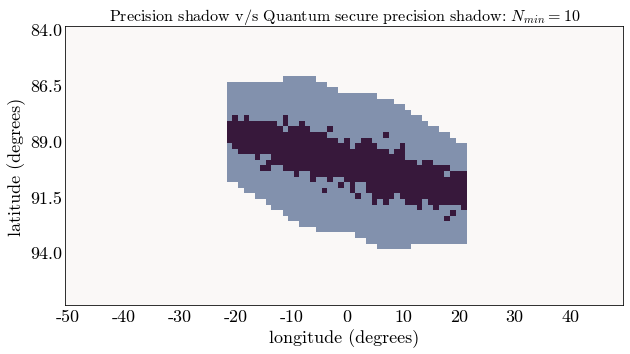

In [25]:
plt.rc('font', family='serif', serif='cmr10')
plt.rcParams['mathtext.fontset'] = 'cm'
'plot formatting'
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection=None)
ax.imshow(pos_prec, cmap='Blues')
ax.imshow(pos_sec, alpha=0.5, cmap='Reds')
plt.title(r"Precision shadow v/s Quantum secure precision shadow: $N_{min} = 10$", fontsize = 16)

ax.set_xlabel('longitude (degrees)', fontsize=18)
ax.set_ylabel('latitude (degrees)', fontsize=18)

x_positions = np.arange(0,100,10)
x_labels = np.array([i-50 for i in np.arange(0,100,10)])
plt.xticks(x_positions, x_labels)

y_positions = np.arange(0,50,10)
y_labels = np.array([i/4+84 for i in np.arange(0,50,10)])
plt.yticks(y_positions, y_labels)

plt.tick_params(axis="x", bottom=False, top=False,
               length=4, width=1.5, direction="in", labelsize=18)
plt.tick_params(axis="y", left=False, right=False,
               length=0, width=1.5, direction="in", labelsize=18)

plt.savefig("Quantum_secure_precision_shadow_N_min_10.pdf")

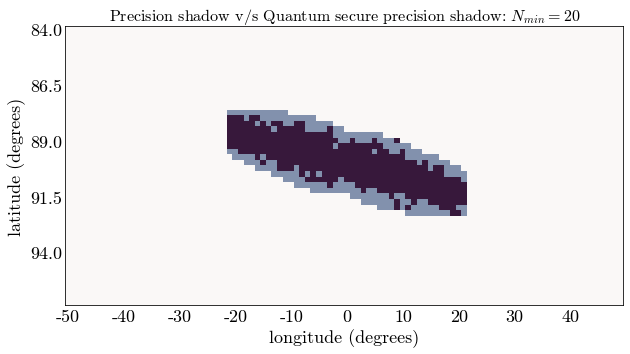

In [23]:
plt.rc('font', family='serif', serif='cmr10')
plt.rcParams['mathtext.fontset'] = 'cm'
'plot formatting'
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection=None)
ax.imshow(pos_prec, cmap='Blues')
ax.imshow(pos_sec, alpha=0.5, cmap='Reds')
plt.title(r"Precision shadow v/s Quantum secure precision shadow: $N_{min} = 20$", fontsize = 16)

ax.set_xlabel('longitude (degrees)', fontsize=18)
ax.set_ylabel('latitude (degrees)', fontsize=18)

x_positions = np.arange(0,100,10)
x_labels = np.array([i-50 for i in np.arange(0,100,10)])
plt.xticks(x_positions, x_labels)

y_positions = np.arange(0,50,10)
y_labels = np.array([i/4+84 for i in np.arange(0,50,10)])
plt.yticks(y_positions, y_labels)

plt.tick_params(axis="x", bottom=False, top=False,
               length=4, width=1.5, direction="in", labelsize=18)
plt.tick_params(axis="y", left=False, right=False,
               length=0, width=1.5, direction="in", labelsize=18)

plt.savefig("Quantum_secure_precision_shadow_N_min_20.pdf")

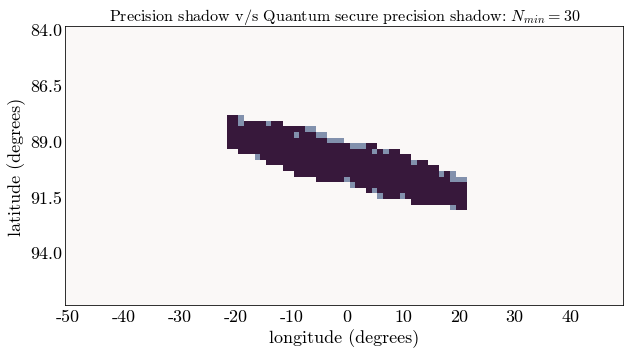

In [29]:
plt.rc('font', family='serif', serif='cmr10')
plt.rcParams['mathtext.fontset'] = 'cm'
'plot formatting'
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection=None)
ax.imshow(pos_prec, cmap='Blues')
ax.imshow(pos_sec, alpha=0.5, cmap='Reds')
plt.title(r"Precision shadow v/s Quantum secure precision shadow: $N_{min} = 30$", fontsize = 16)

ax.set_xlabel('longitude (degrees)', fontsize=18)
ax.set_ylabel('latitude (degrees)', fontsize=18)

x_positions = np.arange(0,100,10)
x_labels = np.array([i-50 for i in np.arange(0,100,10)])
plt.xticks(x_positions, x_labels)

y_positions = np.arange(0,50,10)
y_labels = np.array([i/4+84 for i in np.arange(0,50,10)])
plt.yticks(y_positions, y_labels)

plt.tick_params(axis="x", bottom=False, top=False,
               length=4, width=1.5, direction="in", labelsize=18)
plt.tick_params(axis="y", left=False, right=False,
               length=0, width=1.5, direction="in", labelsize=18)

plt.savefig("Quantum_secure_precision_shadow_N_min_30.pdf")

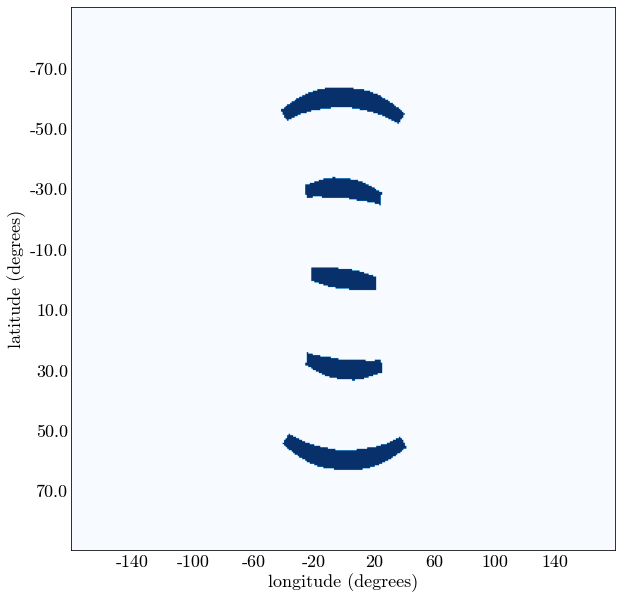

In [36]:
plt.rc('font', family='serif', serif='cmr10')
plt.rcParams['mathtext.fontset'] = 'cm'
'plot formatting'
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection=None)
ax.imshow(pos, cmap='Blues')

ax.set_xlabel('longitude (degrees)', fontsize=18)
ax.set_ylabel('latitude (degrees)', fontsize=18)

plt.tick_params(axis="x", bottom=False, top=False,
               length=4, width=1.5, direction="in", labelsize=18)
plt.tick_params(axis="y", left=False, right=False,
               length=0, width=1.5, direction="in", labelsize=18)

x_positions = np.arange(0,360,40)[1:]
x_labels = np.array([i-180 for i in np.arange(0,360,40)])[1:]
plt.xticks(x_positions, x_labels)

y_positions = np.arange(0,361,40)[1:-1]
y_labels = np.array([i/2-90 for i in np.arange(0,361,40)])[1:-1]
plt.yticks(y_positions, y_labels)

plt.savefig("shadow_horizon_tilt0.pdf" , dpi=600, facecolor='w', edgecolor='w',
    orientation='landscape', format='pdf',
    transparent=False, bbox_inches='tight', pad_inches=0.1)

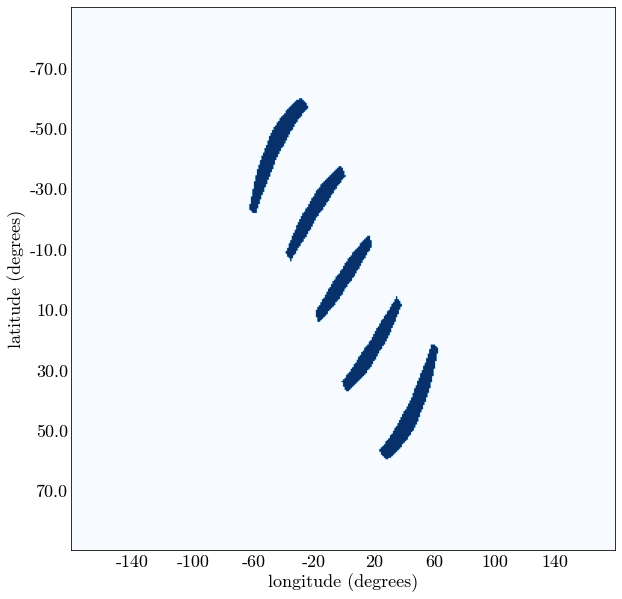

In [31]:
plt.rc('font', family='serif', serif='cmr10')
plt.rcParams['mathtext.fontset'] = 'cm'
'plot formatting'
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection=None)
ax.imshow(pos, cmap='Blues')

ax.set_xlabel('longitude (degrees)', fontsize=18)
ax.set_ylabel('latitude (degrees)', fontsize=18)

plt.tick_params(axis="x", bottom=False, top=False,
               length=4, width=1.5, direction="in", labelsize=18)
plt.tick_params(axis="y", left=False, right=False,
               length=0, width=1.5, direction="in", labelsize=18)

x_positions = np.arange(0,360,40)[1:]
x_labels = np.array([i-180 for i in np.arange(0,360,40)])[1:]
plt.xticks(x_positions, x_labels)

y_positions = np.arange(0,361,40)[1:-1]
y_labels = np.array([i/2-90 for i in np.arange(0,361,40)])[1:-1]
plt.yticks(y_positions, y_labels)

plt.savefig("shadow_horizon_tilt50.pdf" , dpi=600, facecolor='w', edgecolor='w',
    orientation='landscape', format='pdf',
    transparent=False, bbox_inches='tight', pad_inches=0.1)

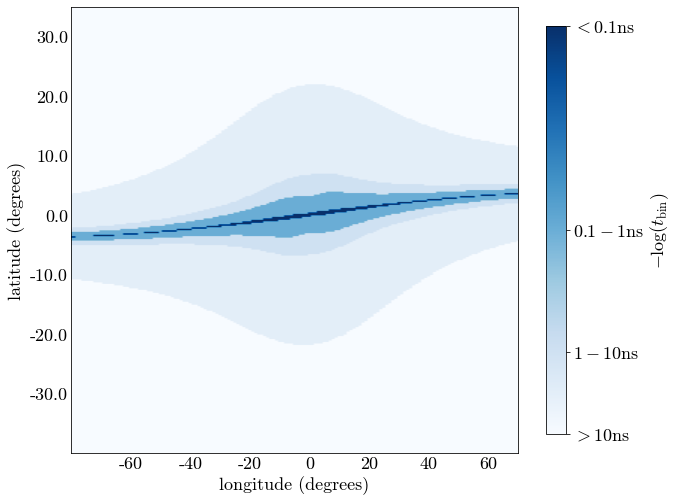

In [92]:
'plot formatting'
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection=None)

cax = ax.imshow(pos, cmap='Blues')

ax.set_xlabel('longitude (degrees)', fontsize=18)
ax.set_ylabel('latitude (degrees)', fontsize=18)

ax.set_xlim(100,250)
ax.set_ylim(200,500)

x_positions = np.arange(100,250,20)[1:]
x_labels = np.array([i-180 for i in range(100,250,20)])[1:]
plt.xticks(x_positions, x_labels)

y_positions = np.arange(200,500,40)[1:]
y_labels = np.array([i/4-90 for i in range(200,500,40)])[1:]
plt.yticks(y_positions, y_labels)
plt.tick_params(axis="x", bottom=False, top=False,
               length=4, width=1.5, direction="in", labelsize=18)
plt.tick_params(axis="y", left=False, right=False,
               length=0, width=1.5, direction="in", labelsize=18)
ratio = 1.0
xleft, xright = ax.get_xlim()
ybottom, ytop = ax.get_ylim()
ax.set_aspect(abs((xright-xleft)/(ybottom-ytop))*ratio)

cbar = fig.colorbar(cax, ticks=[10,5,2,0], shrink=0.75)
cbar.set_label(r'$-\log(t_{\rm bin})$', fontsize=18)
cbar.ax.tick_params(labelsize=18)
cbar.ax.set_yticklabels([r'$< 0.1 \rm ns$', r'$0.1 - 1 \rm ns$', r'$1 - 10 \rm ns$', r'$> 10 \rm ns$'])

plt.savefig("shadow_pc_tilt0.pdf" , dpi=600, facecolor='w', edgecolor='w',
    orientation='landscape', format='pdf',
    transparent=False, bbox_inches='tight', pad_inches=0.1)

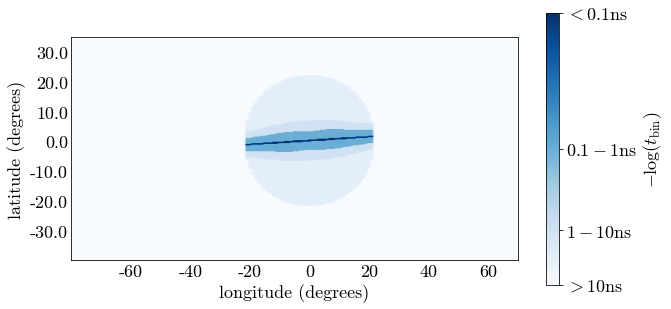

In [94]:
'plot formatting'
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection=None)
cax = ax.imshow(pos, cmap='Blues')

ax.set_xlabel('longitude (degrees)', fontsize=18)
ax.set_ylabel('latitude (degrees)', fontsize=18)

ax.set_xlim(100,250)
ax.set_ylim(200,500)

x_positions = np.arange(100,250,20)[1:]
x_labels = np.array([i-180 for i in range(100,250,20)])[1:]
plt.xticks(x_positions, x_labels)

y_positions = np.arange(200,500,40)[1:]
y_labels = np.array([i/4-90 for i in range(200,500,40)])[1:]
plt.yticks(y_positions, y_labels)
plt.tick_params(axis="x", bottom=False, top=False,
               length=4, width=1.5, direction="in", labelsize=18)
plt.tick_params(axis="y", left=False, right=False,
               length=0, width=1.5, direction="in", labelsize=18)
ratio = 0.5
xleft, xright = ax.get_xlim()
ybottom, ytop = ax.get_ylim()
ax.set_aspect(abs((xright-xleft)/(ybottom-ytop))*ratio)

cbar = fig.colorbar(cax, ticks=[10,5,2,0], shrink=0.5)
cbar.set_label(r'$-\log(t_{\rm bin})$', fontsize=18)
cbar.ax.tick_params(labelsize=18)
cbar.ax.set_yticklabels([r'$< 0.1 \rm ns$', r'$0.1 - 1 \rm ns$', r'$1 - 10 \rm ns$', r'$> 10 \rm ns$',])

plt.savefig("shadow_test_diff_precision.pdf" , dpi=600, facecolor='w', edgecolor='w',
    orientation='landscape', format='pdf',
    transparent=False, bbox_inches='tight', pad_inches=0.1)

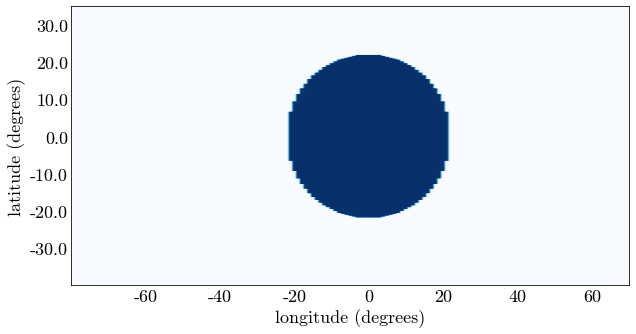

In [69]:
'plot formatting'
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection=None)
ax.imshow(pos, cmap='Blues')

ax.set_xlabel('longitude (degrees)', fontsize=18)
ax.set_ylabel('latitude (degrees)', fontsize=18)

ax.set_xlim(100,250)
ax.set_ylim(200,500)

x_positions = np.arange(100,250,20)[1:]
x_labels = np.array([i-180 for i in range(100,250,20)])[1:]
plt.xticks(x_positions, x_labels)

y_positions = np.arange(200,500,40)[1:]
y_labels = np.array([i/4-90 for i in range(200,500,40)])[1:]
plt.yticks(y_positions, y_labels)
plt.tick_params(axis="x", bottom=False, top=False,
               length=4, width=1.5, direction="in", labelsize=18)
plt.tick_params(axis="y", left=False, right=False,
               length=0, width=1.5, direction="in", labelsize=18)
ratio = 0.5
xleft, xright = ax.get_xlim()
ybottom, ytop = ax.get_ylim()
ax.set_aspect(abs((xright-xleft)/(ybottom-ytop))*ratio)


plt.savefig("shadow_test_visibility.pdf" , dpi=600, facecolor='w', edgecolor='w',
    orientation='landscape', format='pdf',
    transparent=False, bbox_inches='tight', pad_inches=0.1)

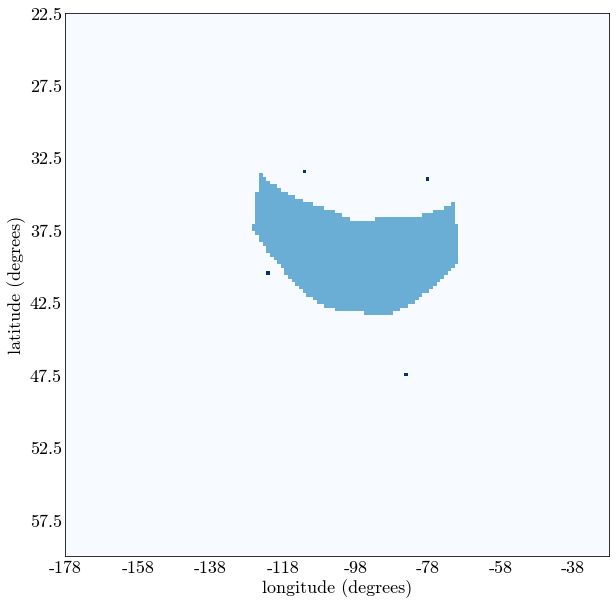

In [133]:
pos[int((90+40.71)*4)][int(180+74-98)] = 10
pos[int((90+33.74)*4)][int(180+84-98)] = 10
pos[int((90+34.05)*4)][int(180+118-98)] = 10
pos[int((90+47.60)*4)][int(180+112-98)] = 10

plt.rc('font', family='serif', serif='cmr10')
plt.rcParams['mathtext.fontset'] = 'cm'
'plot formatting'
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection=None)
ax.imshow(pos, cmap='Blues')

ax.set_xlabel('longitude (degrees)', fontsize=18)
ax.set_ylabel('latitude (degrees)', fontsize=18)

ax.set_xlim(100,250)
ax.set_ylim(600,450)

plt.tick_params(axis="x", bottom=False, top=False,
               length=4, width=1.5, direction="in", labelsize=18)
plt.tick_params(axis="y", left=False, right=False,
               length=0, width=1.5, direction="in", labelsize=18)

x_positions = np.arange(100,250,20)
x_labels = np.array([i-180-98 for i in np.arange(100,250,20)])
plt.xticks(x_positions, x_labels)

y_positions = np.arange(450,600,20)
y_labels = np.array([i/4-90 for i in np.arange(450,600,20)])
plt.yticks(y_positions, y_labels)

plt.savefig("shadow_horizon_4cities.pdf" , dpi=600, facecolor='w', edgecolor='w',
    orientation='landscape', format='pdf',
    transparent=False, bbox_inches='tight', pad_inches=0.1)